In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

100%|██████████| 2.44M/2.44M [00:03<00:00, 785kB/s]

Extracting files...
Path to dataset files: C:\Users\BIT\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
# Load the dataset
os.listdir(path)

['AB_NYC_2019.csv', 'New_York_City_.png']

In [23]:
file_path = os.path.join(path, 'AB_NYC_2019.csv')
df = pd.read_csv(file_path)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [24]:
df['name']=df['name'].str.title()
df['host_name']=df['host_name'].str.title()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [26]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47487,NaN,11428,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Home Away From Home,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,33,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [27]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [28]:
df.shape

(48895, 16)

In [29]:
clean_df=df.copy()

In [30]:
clean_df.columns=clean_df.columns.str.strip().str.lower().str.replace(' ', '_'  )

In [31]:
missing_percent=clean_df.isnull().sum()/len(clean_df)*100
missing_percent.sort_values(ascending=False)

last_review                       20.558339
reviews_per_month                 20.558339
host_name                          0.042949
name                               0.032723
neighbourhood_group                0.000000
neighbourhood                      0.000000
id                                 0.000000
host_id                            0.000000
longitude                          0.000000
latitude                           0.000000
room_type                          0.000000
price                              0.000000
number_of_reviews                  0.000000
minimum_nights                     0.000000
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

In [32]:
clean_df['reviews_per_month']=clean_df['reviews_per_month'].fillna(0)

In [33]:
clean_df.dropna(subset=['name','host_name'], inplace=True)

In [34]:
clean_df.duplicated().sum()

np.int64(0)

In [35]:
clean_df.drop_duplicates(inplace=True)

In [36]:
clean_df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [37]:
clean_df['last_review']=pd.to_datetime(clean_df['last_review'], errors='coerce')    

In [38]:
clean_d=clean_df[clean_df['price']>0]

In [39]:
clean_df=clean_df[clean_df['minimum_nights']>0]

In [40]:
text_columns=['neighbourhood_group','neighbourhood','room_type']
for col in text_columns:
    clean_df[col]=clean_df[col].str.lower().str.strip()

Text(0.5, 1.0, 'Boxplot of Price')

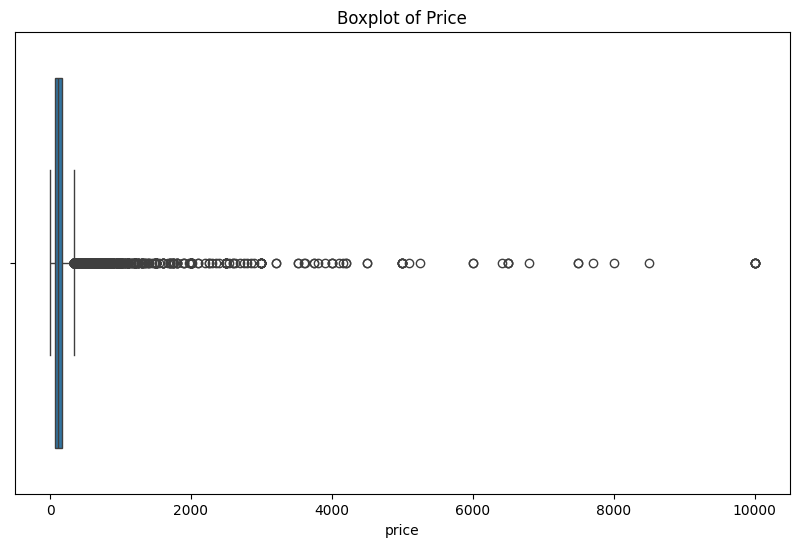

In [42]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(x=clean_df['price'])
plt.title('Boxplot of Price')

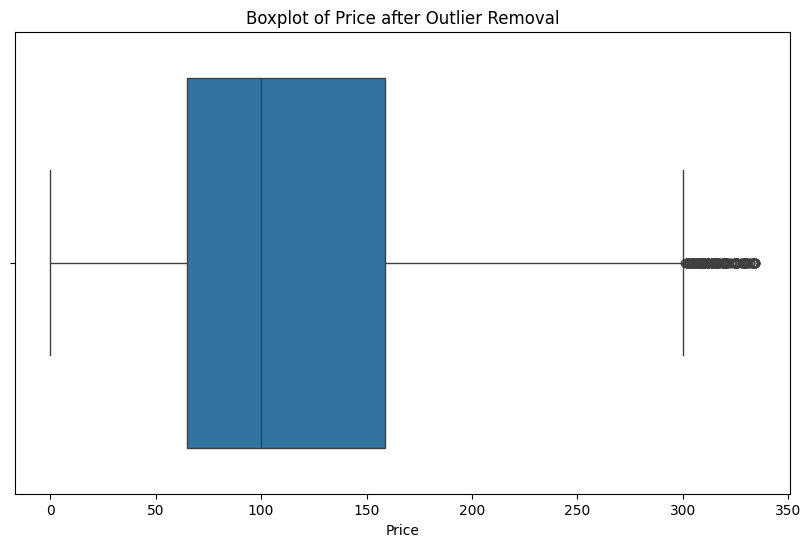

In [43]:
Q1=clean_df['price'].quantile(0.25)
Q3=clean_df['price'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
clean_df=clean_df[(clean_df['price']>=lower_bound) & (clean_df['price']<=upper_bound)]
plt.figure(figsize=(10,6))
sns.boxplot(x=clean_df['price'])
plt.title('Boxplot of Price after Outlier Removal')
plt.xlabel('Price')
plt.show()

In [45]:
clean_df['price_category']=pd.cut(clean_df['price'], bins=[0,50,150,300,1000], labels=['Budgets','Moderate','Premium','Luxury'])

In [48]:
clean_df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
price_category                    0
dtype: int64

In [49]:
clean_df.duplicated().sum()

np.int64(0)

In [50]:
clean_df.to_csv('cleaned_airbnb_data.csv', index=False)

In [51]:
report={
    "Original Rows": len(df),
    "Cleaned Rows": len(clean_df),
    "Rows Removed": len(df)-len(clean_df),
    "Duplicate Rows Removed": df.duplicated().sum(),
    "Missing Values Remaining": clean_df.isnull().sum().sum(),

}
print(report)

{'Original Rows': 48895, 'Cleaned Rows': 36879, 'Rows Removed': 12016, 'Duplicate Rows Removed': np.int64(0), 'Missing Values Remaining': np.int64(0)}
